# Lab 3 - Clustering

## Workflow



Trước khi tiến hành áp dụng các thuật toán phân cụm với bài thực hành lần này, ta cần phải xác định được vấn đề của bài toán đưa ra, khảo sát, phân tích, tiền xử lý và tiến hành `Feature Engineering` với tập dữ liệu phù hợp.

Trong notebook này, bước đầu tiên là tiến hành EDA với tập dữ liệu đã thu thập được. Workflow dự kiến của notebook này được tiến hành theo thứ tự như sau:

```mermaid
flowchart TD
    A[Load Dataset] --> B[Data Overview]
    B --> C[Missing Values / NaN / Null Analysis]
    C --> D[Univariate Analysis]
    D --> E[Bivariate / Multivariate Analysis]
    E --> F[Outlier Analysis]
    F --> G[HTML Visualization Report]
```

## Xác định vấn đề 

### Bối cảnh bài toán

Một công ty chuyên kinh doanh ô tô đang có kế hoạch mở rộng sang một thị trường mới với các dòng sản phẩm hiện có ($P_1, P_2, P_3, P_4, P_5$). Dựa trên các khảo sát sơ bộ, công ty đưa ra giả định rằng đặc điểm nhân khẩu học cũng như mức độ chi tiêu (Spending Score) của khách hàng tại thị trường mới có nhiều nét tương đồng với tập khách hàng hiện tại.

Tuy nhiên, tập khách hàng hiện tại vẫn chưa được phân chia thành các phân khúc cụ thể. Điều này gây khó khăn trong việc xác định nhóm khách hàng mục tiêu và xây dựng các chiến lược kinh doanh phù hợp khi mở rộng sang thị trường mới.

Do đó, bài toán đặt ra là áp dụng các thuật toán Học không giám sát (*Unsupervised Learning*) nhằm khám phá và phân cụm các nhóm khách hàng dựa trên sự tương đồng giữa các đặc trưng của họ. Kết quả phân cụm thu được sẽ giúp doanh nghiệp hiểu rõ hơn cấu trúc khách hàng hiện tại, từ đó đưa ra cơ sở tham khảo cho việc nghiên cứu và xây dựng chiến lược tiếp cận thị trường mới một cách hiệu quả hơn.

## 1. Data Overview

### Nguồn dữ liệu thu thập

Nguồn gốc dữ liệu ban đầu có chứa nhãn `Segmentation`, tuy nhiên do mục tiêu của bài toán là áp dụng các thuật toán Học không giám sát (Unsupervised Learning), thuộc tính này sẽ được loại bỏ trong quá trình xây dựng mô hình. Việc phân cụm khách hàng sẽ được thực hiện hoàn toàn dựa trên các `features` của khách hàng mà không sử dụng `Segmentation`.

* Nguồn dữ liệu: [Kaggle](href=https://www.kaggle.com/datasets/vetrirah/customer/data)
* Cấu trúc dữ liệu: `train` và `test`
* Số lượng `samples` (Trong tập train): 8068 samples và 10 features (Không tính Segmentation)
* Đặc điểm Feature:
    - ID: ID của khách hàng (Unique)
    - Gender: Giới tính     
    - Ever_Married: Tình trạng hôn nhân    
    - Age: Tuổi của khách hàng
    - Graduated: Khách hàng đã tốt nghiệp (bậc Đại học) hay chưa
    - Profession: Nghề nghiệp của khách hàng   
    - Work_Experience:  Số năm kinh nghiệm làm việc của khách hàng
    - Spending_Score: Mức độ chi tiêu của khách hàng ấy
    - Family_Size: Số lượng thành viên gia đình củaách hàng (Tính cả khách hàng ấy)
    - Var_1: Một thuộc tính đã được ẩn danh, chưa rõ ý nghĩa thực tế


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [28]:
df = pd.read_csv('./data/raw/Train.csv')
warnings.filterwarnings('ignore')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


### Features Type

Dựa vào kiểu dữ liệu của các features thông qua quá trình khảo sát sơ bộ tập dữ liệu, ta có thể đưa ra các giả thiết sau và cần được kiểm chứng ở các giai đoạn tiếp theo:
* `ID` có khả năng là biến định danh khách hàng theo `ID`. Tuy nhiên, ta cần phải kiểm chứng kĩ hơn xem chúng thực sự có unique không, từ đó đưa ra kết luận phù hợp về mức độ đóng góp của chúng trong bài toán phân cụm.
* Các biến `Gender, Ever_Married, Var_1` có khả năng là biến phân loại kiểu `str.` `Profession` có thể là một biến phân loại theo nhóm nghề nghiệp khác nhau của khách hàng.
* Các biến `Age, Family_Size, Work_Experience` là các biến định lượng (numerical values).
* `Spending_Score`, thay vì được biểu diễn định lượng (tức là numerical values), thì chúng lại được biểu diễn thông qua kiểu `str`, có thể chúng là biến phân loại mô tả mức độ chi tiêu của khách hàng thông qua các mức độ `Low`, `High` hoặc `Average`.

In [8]:
# Drop col Segmentation
eda_df = df.copy()
eda_df = eda_df.drop(columns=['Segmentation'])

# Preview eda_df sau khi drop Segmentation
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 630.4 KB


## 2. Missing Values Analysis

In [29]:
def analyze_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Phân tích dữ liệu bị Missing (Số lượng samples bị thiếu theo Feature | Phần trăm missing values/tổng sample | Unique values theo feature)
    """
    result = pd.DataFrame({
        "feature": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing_samples": df.isnull().sum().values,
        "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2).values,
        "n_unique": df.nunique(dropna=True).values,
        "is_unique": (df.nunique(dropna=True) == len(df)).values
    })

    return (
        result
        .reset_index(drop=True)
    )

missing_df = analyze_missing_values(eda_df)

display(missing_df)

,feature,dtype,missing_samples,missing_percentage,n_unique,is_unique
0,ID,int64,0,0.00,8068,True
1,Gender,str,0,0.00,2,False
2,Ever_Married,str,140,1.74,2,False
3,Age,int64,0,0.00,67,False
4,Graduated,str,78,0.97,2,False
5,Profession,str,124,1.54,9,False
6,Work_Experience,float64,829,10.28,15,False
7,Spending_Score,str,0,0.00,3,False
8,Family_Size,float64,335,4.15,9,False
9,Var_1,str,76,0.94,7,False


Từ tỷ lệ dữ liệu khuyết thiếu, có thể rút ra một số nhận xét ban đầu như sau. Ngoại trừ các thuộc tính `ID`, `Gender`, `Age` và `Spending_Score`, toàn bộ các đặc trưng còn lại đều tồn tại dữ liệu bị khuyết thiếu, với tỷ lệ thiếu mẫu theo từng đặc trưng dao động từ khoảng **0.94% đến 10.28%**.

Nhìn chung, phần lớn các thuộc tính có tỷ lệ dữ liệu khuyết thiếu tương đối thấp (*<5%*), riêng `Work_Experience` có tỷ lệ thiếu lên đến khoảng *10.28%*, do đó cần được phân tích kỹ hơn ở các bước tiếp theo nhằm đưa ra quyết định phù hợp giữa việc giữ lại và tiến hành xử lý dữ liệu khuyết thiếu hay loại bỏ thuộc tính này khỏi quá trình phân cụm.

* Nhóm các features không bị khuyết thiếu:

    - `ID` không chứa dữ liệu khuyết thiếu và xuất hiện với 8068 ID khác nhau, bằng với số lượng samples của tập dữ liệu. Điều này cho thấy mỗi sample tương ứng với một khách hàng riêng biệt. Tuy nhiên, cần đánh giá thêm xem thuộc tính này có thực sự mang ý nghĩa đối với bài toán phân cụm hay chỉ đóng vai trò định danh khách hàng.

    - `Gender` phân loại khách hàng theo hai nhóm giới tính và không tồn tại dữ liệu khuyết thiếu.

    - `Age` biểu diễn độ tuổi của khách hàng, không chứa dữ liệu khuyết thiếu và có 67 giá trị khác nhau trong tập dữ liệu. Điều này cho thấy tệp khách hàng của công ty trải rộng trên nhiều độ tuổi khác nhau. Tuy nhiên, cần tiến hành phân tích sâu hơn thông qua các bước EDA tiếp theo để đánh giá phân bố thực tế của độ tuổi khách hàng.

    - `Spending_Score` không chứa dữ liệu khuyết thiếu và được biểu diễn thông qua ba mức độ chi tiêu là `Low`, `Average` và `High` thay vì các giá trị số liên tục.

* Nhóm các features bị khuyết thiếu:

    - `var_1` chính là biến dùng để phân loại khách hàng ẩn danh, tỉ lệ thiếu của chúng chiếm thấp nhất trong tập dữ liệu này, với `0.94%`. Tuy nhiên, chúng ta vẫn chưa rõ quan hệ của chúng với các features khác là gì, nên ta sẽ tiếp tục làm rõ thêm ở các giai đoạn tiếp theo.
    - Tiếp theo là `Graduated`, dùng để mô tả việc khách hàng đã tốt nghiệp bậc Cử nhân (Đại học) hay chưa. Tỷ lệ dữ liệu khuyết thiếu của thuộc tính này chỉ chiếm khoảng 0.97% tổng số samples của dataset. Nhóm sẽ khảo sát mối liên hệ giữa Graduated và thuộc tính Profession, nhằm xác định xem liệu dữ liệu khuyết thiếu của hai thuộc tính này có xuất hiện độc lập hay tồn tại một quy luật nhất định.
    - `Profession` thể hiện nhóm ngành nghề của khách hàng và bao gồm 9 nhóm nghề nghiệp khác nhau. Tỷ lệ dữ liệu khuyết thiếu của thuộc tính này chiếm khoảng *1.54%* tổng số samples của dataset. Nhóm đưa ra giả thuyết rằng những khách hàng để trống thông tin nghề nghiệp có thể thuộc một số nhóm đối tượng đặc biệt, chẳng hạn như khách hàng chưa có công việc ổn định hoặc chưa hoàn thành bậc Đại học, từ đó chưa có nghề nghiệp cụ thể. Do đó, cần tiếp tục kiểm tra mối quan hệ giữa `Profession` và `Graduated` để xác minh giả thuyết này.
    - Tiếp đến là tình trạng hôn nhân của khách hàng `Ever_Married`, với tỉ lệ thiếu so với samples dataset là *1.74%*. 
    - Hai feature có tỷ lệ missing cao nhất là `Family_Size` và `Work_Experience`, lần lượt chiếm khoảng `4.15%` và `10.28%` tổng số mẫu. Trong đó, `Work_Experience` có tỷ lệ missing cao hơn khoảng `2.48` lần so với `Family_Size`. Vì vậy, `Work_Experience` cần được phân tích kỹ hơn trước khi quyết định giữ lại, imputing, tạo nhóm `Unknown`, hoặc loại bỏ khỏi quá trình phân cụm.

#### 2.1. Tỉ lệ missing values theo các Features

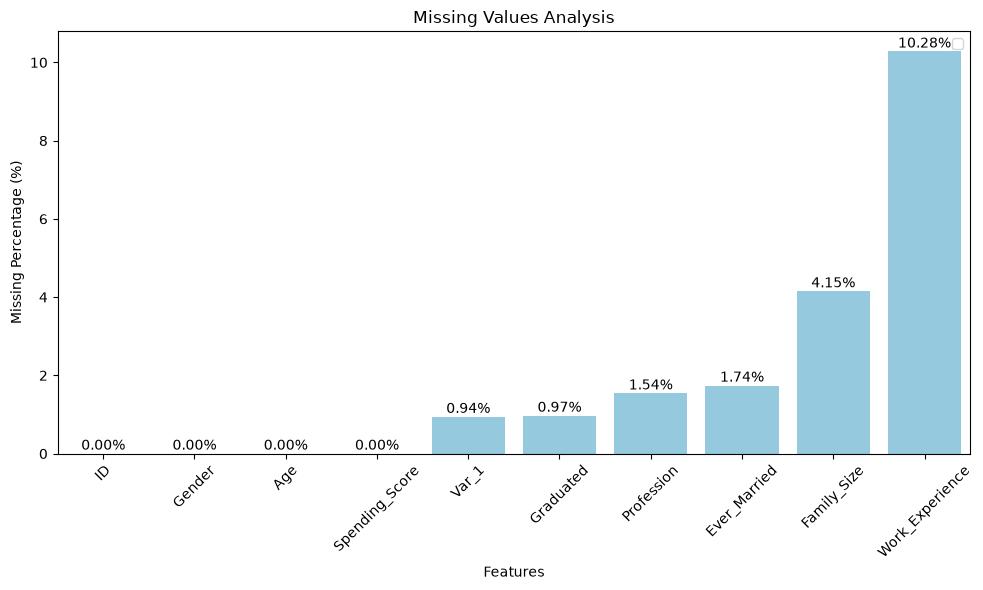

In [30]:
plt.figure(figsize=(10, 6))

plt_data = missing_df.sort_values(by='missing_percentage',ascending=True)

ax = sns.barplot(
    data= plt_data,
    x='feature',
    y='missing_percentage',
    hue='feature',
    palette=[
       'skyblue'
        for x in plt_data['missing_percentage']
    ],
    legend=False
)


for i, value in enumerate(plt_data['missing_percentage']):
    ax.text(
        i,
        value + 0.1,
        f'{value:.2f}%',
        ha='center'
    )

plt.xticks(rotation=45)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Features')
plt.title('Missing Values Analysis')
plt.legend()

plt.tight_layout()
plt.show()

#### 2.2. Heatmap tương quan giữa các Missing Values theo Features

Nhằm làm rõ liệu dữ liệu khuyết thiếu của các thuộc tính có xuất hiện đồng thời theo một quy luật nhất định hay không, nhóm tiến hành khảo sát hệ số tương quan giữa các Missing Values. Kết quả cho thấy phần lớn các cặp thuộc tính có hệ số tương quan rất thấp (dao động từ khoảng *0* đến *0.07*). Điều này cho thấy dữ liệu khuyết thiếu giữa các đặc trưng gần như xuất hiện độc lập với nhau và chưa quan sát được một pattern rõ ràng.


Đặc biệt, mối liên hệ giữa `Graduated` và `Profession` chỉ đạt khoảng 0.06, cho thấy giả thuyết ban đầu về việc khách hàng chưa tốt nghiệp dẫn đến thiếu thông tin nghề nghiệp chưa được thể hiện rõ ràng trong biểu đồ tương quan.

Do đó, ở thời điểm hiện tại, nhóm chưa có đủ cơ sở để kết luận rằng các Missing Values xuất hiện theo một quy luật nhất định. Các thuộc tính chứa dữ liệu khuyết thiếu sẽ tiếp tục được khảo sát trong những bước EDA tiếp theo trước khi đưa ra phương án xử lý phù hợp.

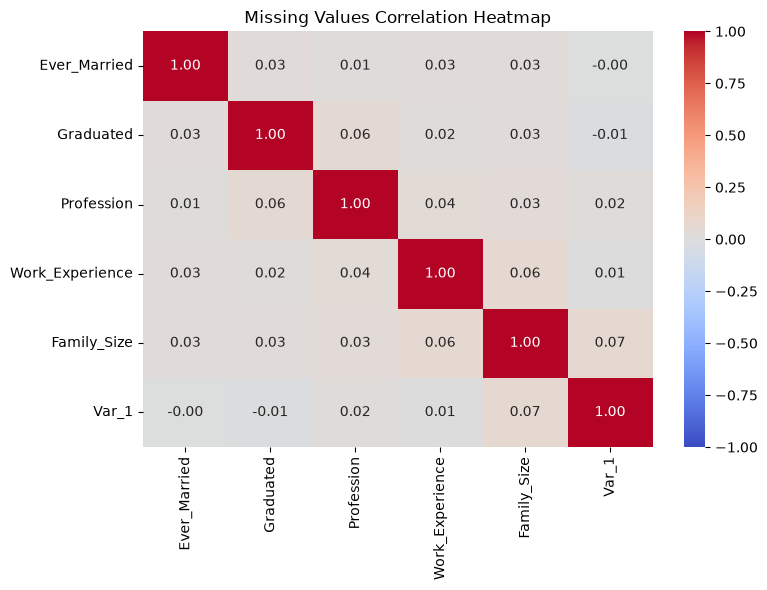

In [32]:
# Chỉ lấy các feature có tồn tại Missing Values
missing_features = eda_df.columns[eda_df.isnull().sum() > 0]

# Correlation giữa các Missing Values
missing_corr = eda_df[missing_features].isnull().corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    missing_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Missing Values Correlation Heatmap')

plt.tight_layout()
plt.show()

## 3. Univariate Analysis

Ở bước **Univariate Analysis**, nhóm sẽ tiến hành phân tích từng đặc trưng một cách độc lập nhằm hiểu rõ hơn đặc điểm phân bố của dữ liệu. Các đặc trưng sẽ được chia thành hai nhóm chính:

* **Numerical Features**: tiến hành khảo sát các thống kê mô tả cơ bản, phân phối dữ liệu (*Distribution Plot*), *Skewness* và sự xuất hiện của các điểm ngoại lai (*Outliers*).

* **Categorical Features**: tiến hành khảo sát tần suất, tỷ lệ xuất hiện của từng nhóm giá trị và trực quan hóa phân bố của chúng thông qua các biểu đồ phù hợp.

Thông qua quá trình phân tích đơn biến, nhóm kỳ vọng có thể hiểu rõ hơn đặc điểm của từng feature, từ đó hỗ trợ cho việc phát hiện các bất thường trong dữ liệu và đưa ra các quyết định phù hợp.


In [47]:
# Phân loại Numerical Features và Categorical Features
# Loại ID Feature
# Categorical Features:
#   - dtype thuộc object/string/category
#   - hoặc số lượng unique values < 9
# Numerical Features:
#   - các feature còn lại

cat_features = [
    col
    for col in eda_df.columns
    if (
        eda_df[col].dtype == 'str'
        and col != 'ID'
        or eda_df[col].nunique()<9
    )
]

num_features = eda_df.columns[
    ~eda_df.columns.isin(cat_features + ['ID'])
].tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)


Numerical Features: ['Age', 'Work_Experience', 'Family_Size']
Categorical Features: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


#### 3.1. Numerical Features

##### a. Basic Stats

Với kết quả thống kê mô tả cơ bản, có thể rút ra một số nhận xét ban đầu như sau:

* Độ tuổi của khách hàng trải dài từ 18 đến 89 tuổi, với độ tuổi trung bình khoảng 43 tuổi và độ tuổi trung vị là 40 tuổi. Điều này cho thấy tập khách hàng của công ty bao gồm nhiều nhóm tuổi khác nhau.

* Số năm kinh nghiệm làm việc của khách hàng dao động từ 0 đến 14 năm, với giá trị trung bình khoảng 2.64 năm trong khi giá trị trung vị chỉ đạt 1 năm. Điều này cho thấy phần lớn khách hàng trong tập dữ liệu có số năm kinh nghiệm tương đối thấp.

* Quy mô gia đình của khách hàng dao động từ 1 đến 9 thành viên, với giá trị trung bình khoảng 2.85 người và giá trị trung vị bằng 3 người. Khoảng 50% khách hàng trong tập dữ liệu có quy mô gia đình nằm trong khoảng từ 2 đến 4 thành viên. Điều này cho thấy phần lớn khách hàng thuộc nhóm gia đình quy mô nhỏ hoặc trung bình.

In [48]:
display(eda_df[num_features].describe().round(2))

,Age,Work_Experience,Family_Size
count,8068.00,7239.00,7733.00
mean,43.47,2.64,2.85
std,16.71,3.41,1.53
min,18.00,0.00,1.00
25%,30.00,0.00,2.00
50%,40.00,1.00,3.00
75%,53.00,4.00,4.00
max,89.00,14.00,9.00


##### b. Distribution và Skewness

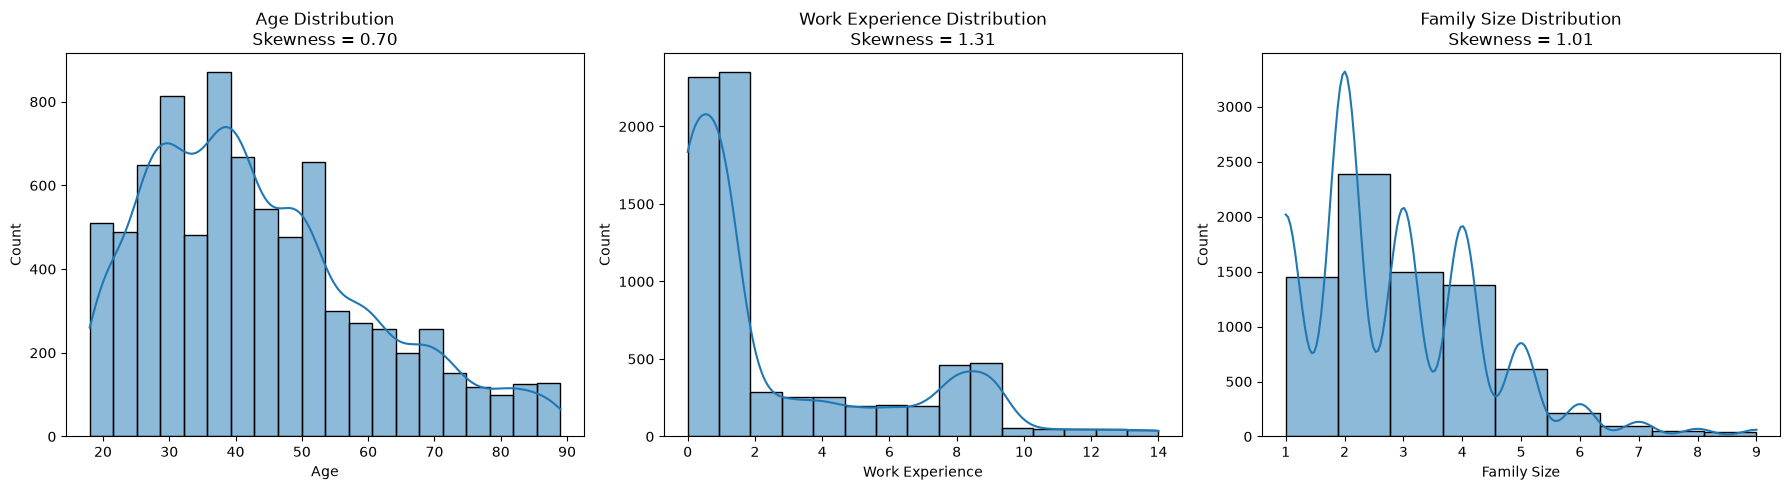

In [50]:
# Tính skewness
skews = {
    col: eda_df[col].skew(skipna=True)
    for col in num_features
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Age
sns.histplot(
    data=eda_df,
    x='Age',
    kde=True,
    bins=20,
    ax=axes[0]
)
axes[0].set_title(f'Age Distribution\nSkewness = {skews["Age"]:.2f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Work Experience
sns.histplot(
    data=eda_df,
    x='Work_Experience',
    kde=True,
    bins=15,
    ax=axes[1]
)
axes[1].set_title(f'Work Experience Distribution\nSkewness = {skews["Work_Experience"]:.2f}')
axes[1].set_xlabel('Work Experience')
axes[1].set_ylabel('Count')

# Family Size
sns.histplot(
    data=eda_df,
    x='Family_Size',
    kde=True,
    bins=9,
    ax=axes[2]
)
axes[2].set_title(f'Family Size Distribution\nSkewness = {skews["Family_Size"]:.2f}')
axes[2].set_xlabel('Family Size')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

Thông qua các biểu đồ Histogram kết hợp với hệ số Skewness, có thể nhận thấy cả ba thuộc tính đều có xu hướng lệch phải ở các mức độ khác nhau. Tuy nhiên, mức độ bất đối xứng của từng thuộc tính là không giống nhau.

* Đối với `Age`, phân phối của dữ liệu tương đối tập trung trong khoảng từ 30-50 tuổi, với đỉnh phân phối nằm xung quanh nhóm tuổi 35-40. Mặc dù vẫn tồn tại một số khách hàng ở nhóm tuổi cao hơn, số lượng của chúng có xu hướng giảm dần về phía cuối phân phối. Điều này cho thấy tập khách hàng của công ty chủ yếu tập trung ở nhóm khách hàng trung niên. Với hệ số Skewness khoảng `0.71`, `Age` là thuộc tính có mức độ lệch phải thấp nhất trong ba `Numerical Features`.

* Đối với `Work_Experience`, phần lớn khách hàng tập trung ở nhóm có từ 0-2 năm kinh nghiệm. Sau khoảng này, tần suất xuất hiện giảm mạnh. Tuy nhiên, biểu đồ còn cho thấy một sự gia tăng nhẹ ở nhóm khách hàng có khoảng 8-9 năm kinh nghiệm thay vì giảm đều hoàn toàn. Với hệ số Skewness đạt `1.31`, `Work_Experience` là thuộc tính có mức độ lệch phải mạnh nhất trong ba thuộc tính số.

* Đối với `Family_Size`, phần lớn khách hàng có quy mô gia đình từ 2-4 thành viên, trong đó nhóm 2-3 thành viên xuất hiện nhiều nhất. Sau mốc này, số lượng khách hàng giảm dần khi quy mô gia đình tăng lên. Thuộc tính này cũng có xu hướng lệch phải, tuy nhiên mức độ skewness của chúng không mạnh bằng `Work_Experience` và nằm ở mức giữa `Age` và `Work_Experience`.

Nhìn chung, cả ba thuộc tính số đều không tuân theo phân phối chuẩn hoàn toàn, trong đó `Work_Experience` thể hiện mức độ lệch phải rõ rệt nhất.

##### c. Outlier Detection

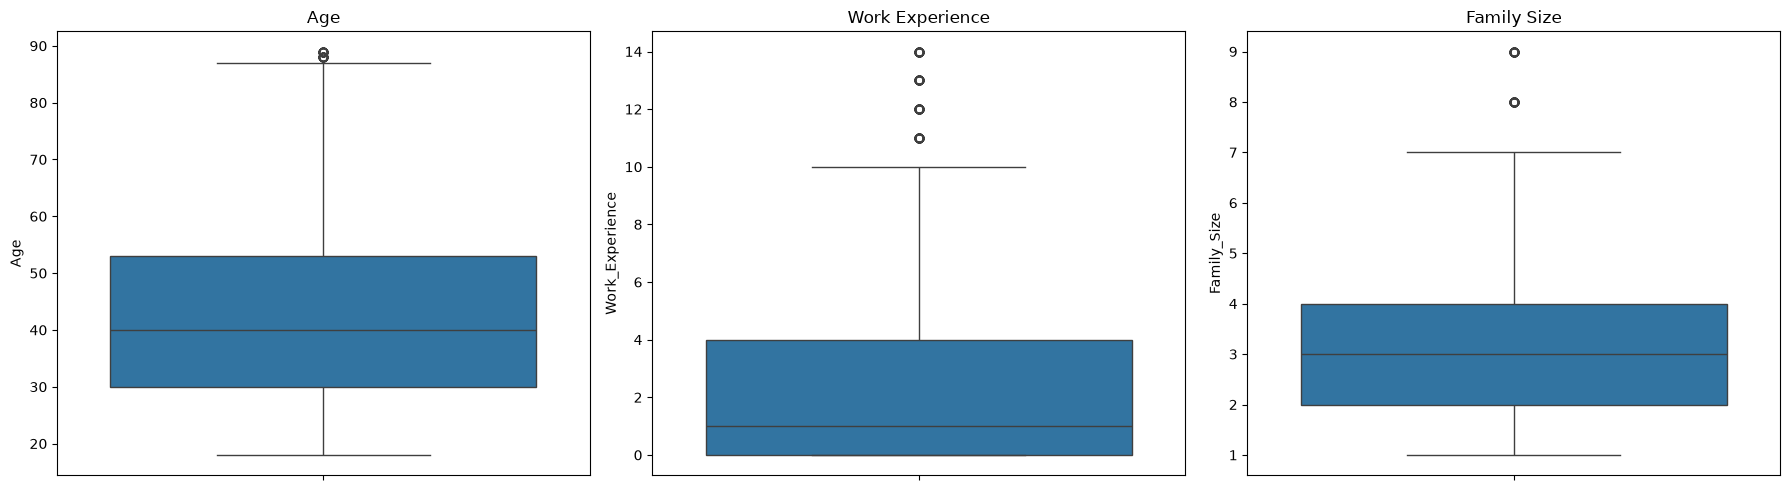

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=eda_df['Age'], ax=axes[0])
axes[0].set_title('Age')

sns.boxplot(y=eda_df['Work_Experience'], ax=axes[1])
axes[1].set_title('Work Experience')

sns.boxplot(y=eda_df['Family_Size'], ax=axes[2])
axes[2].set_title('Family Size')

plt.tight_layout()
plt.show()

Thông qua biểu đồ Boxplot, nhóm rút ra một số nhận xét như sau:

* Đối với thuộc tính `Age`, phần lớn khách hàng tập trung ở nhóm tuổi trung niên (~30-50 tuổi), với trung vị nằm xấp xỉ 40 tuổi. Khoảng 50% số khách hàng có độ tuổi nằm trong khoảng từ 30 đến 53 tuổi. Lower whisker trải dài từ khoảng 18 đến 30 tuổi, trong khi upper whisker kéo dài đến khoảng 85 tuổi. Ngoài ra, một số giá trị ngoại lai xuất hiện ở nhóm khách hàng từ khoảng 86-89 tuổi. Tuy nhiên, các giá trị này vẫn phù hợp với thực tế và không thể hiện sự bất thường rõ rệt.

* Đối với thuộc tính `Work_Experience`, phần lớn khách hàng có số năm kinh nghiệm từ 0 đến 4 năm, với trung vị chỉ khoảng 1 năm. Khoảng 50% khách hàng có số năm kinh nghiệm nằm trong khoảng từ 0 đến 4 năm. Upper whisker kéo dài đến khoảng 10 năm kinh nghiệm, trong khi các giá trị từ 11-14 năm xuất hiện dưới dạng outliers. So với hai thuộc tính còn lại, `Work_Experience` xuất hiện nhiều giá trị ngoại lai rõ rệt hơn và cũng phù hợp với nhận định trước đó về sự lệch phải mạnh của thuộc tính này.

* Đối với thuộc tính `Family_Size`, phần lớn khách hàng có quy mô gia đình từ 2 đến 4 thành viên, với trung vị là 3 thành viên. Lower whisker trải dài từ 1 đến 2 thành viên và không xuất hiện giá trị ngoại lai ở phía dưới. Upper whisker kéo dài đến khoảng 7 thành viên, trong khi các gia đình có từ 8-9 thành viên xuất hiện dưới dạng outliers. Tuy nhiên, các giá trị này vẫn hoàn toàn có thể xảy ra trong thực tế và chưa đủ cơ sở để xem là các bất thường cần loại bỏ.

#### 3.2. Categorical Features

Phần lớn các thuộc tính phân loại đều thể hiện sự mất cân bằng nhất định giữa các nhóm giá trị. Tuy nhiên, mức độ imbalanced là không giống nhau giữa các features.

- Tỷ lệ Nam/Nữ tương đối cân bằng, với nhóm khách hàng Nam chiếm tỷ lệ nhỉnh hơn nhóm khách hàng Nữ (54.74% so với 45.26%).

- Tương tự, tỷ lệ khách hàng đã kết hôn cũng cao hơn so với nhóm khách hàng chưa kết hôn (58.56% so với 41.43%).

- Nhóm khách hàng đã tốt nghiệp bậc Cử nhân (Đại học) chiếm tỷ lệ cao hơn đáng kể so với nhóm chưa tốt nghiệp.

- Đối với thuộc tính `Profession`, nhóm `Artist` chiếm tỷ lệ cao nhất (31.67%) trong số các khách hàng có thông tin nghề nghiệp. Tuy nhiên, do không có thông tin về phương pháp thu thập dữ liệu cũng như định nghĩa cụ thể của từng nhóm nghề nghiệp, nhóm chưa có đủ cơ sở để kết luận rằng sự phân bố này phản ánh đúng hay sai thực tế.

- Đối với thuộc tính `Spending_Score`, phần lớn khách hàng thuộc nhóm có mức độ chi tiêu thấp (`Low`), chiếm khoảng 60.46% tổng số khách hàng, tiếp theo là nhóm `Average` và cuối cùng là nhóm `High`. Điều này cho thấy phân phối của thuộc tính này tương đối mất cân bằng.

- Thuộc tính `Var_1` cũng thể hiện sự mất cân bằng đáng kể giữa các nhóm giá trị, với `Cat_6` chiếm tới 65.54% số lượng khách hàng có thông tin `Var_1`. Tuy nhiên, do ý nghĩa thực tế của thuộc tính này không được rõ ràng, nhóm chưa thể đánh giá được mức độ ảnh hưởng của nó đối với bài toán phân cụm.


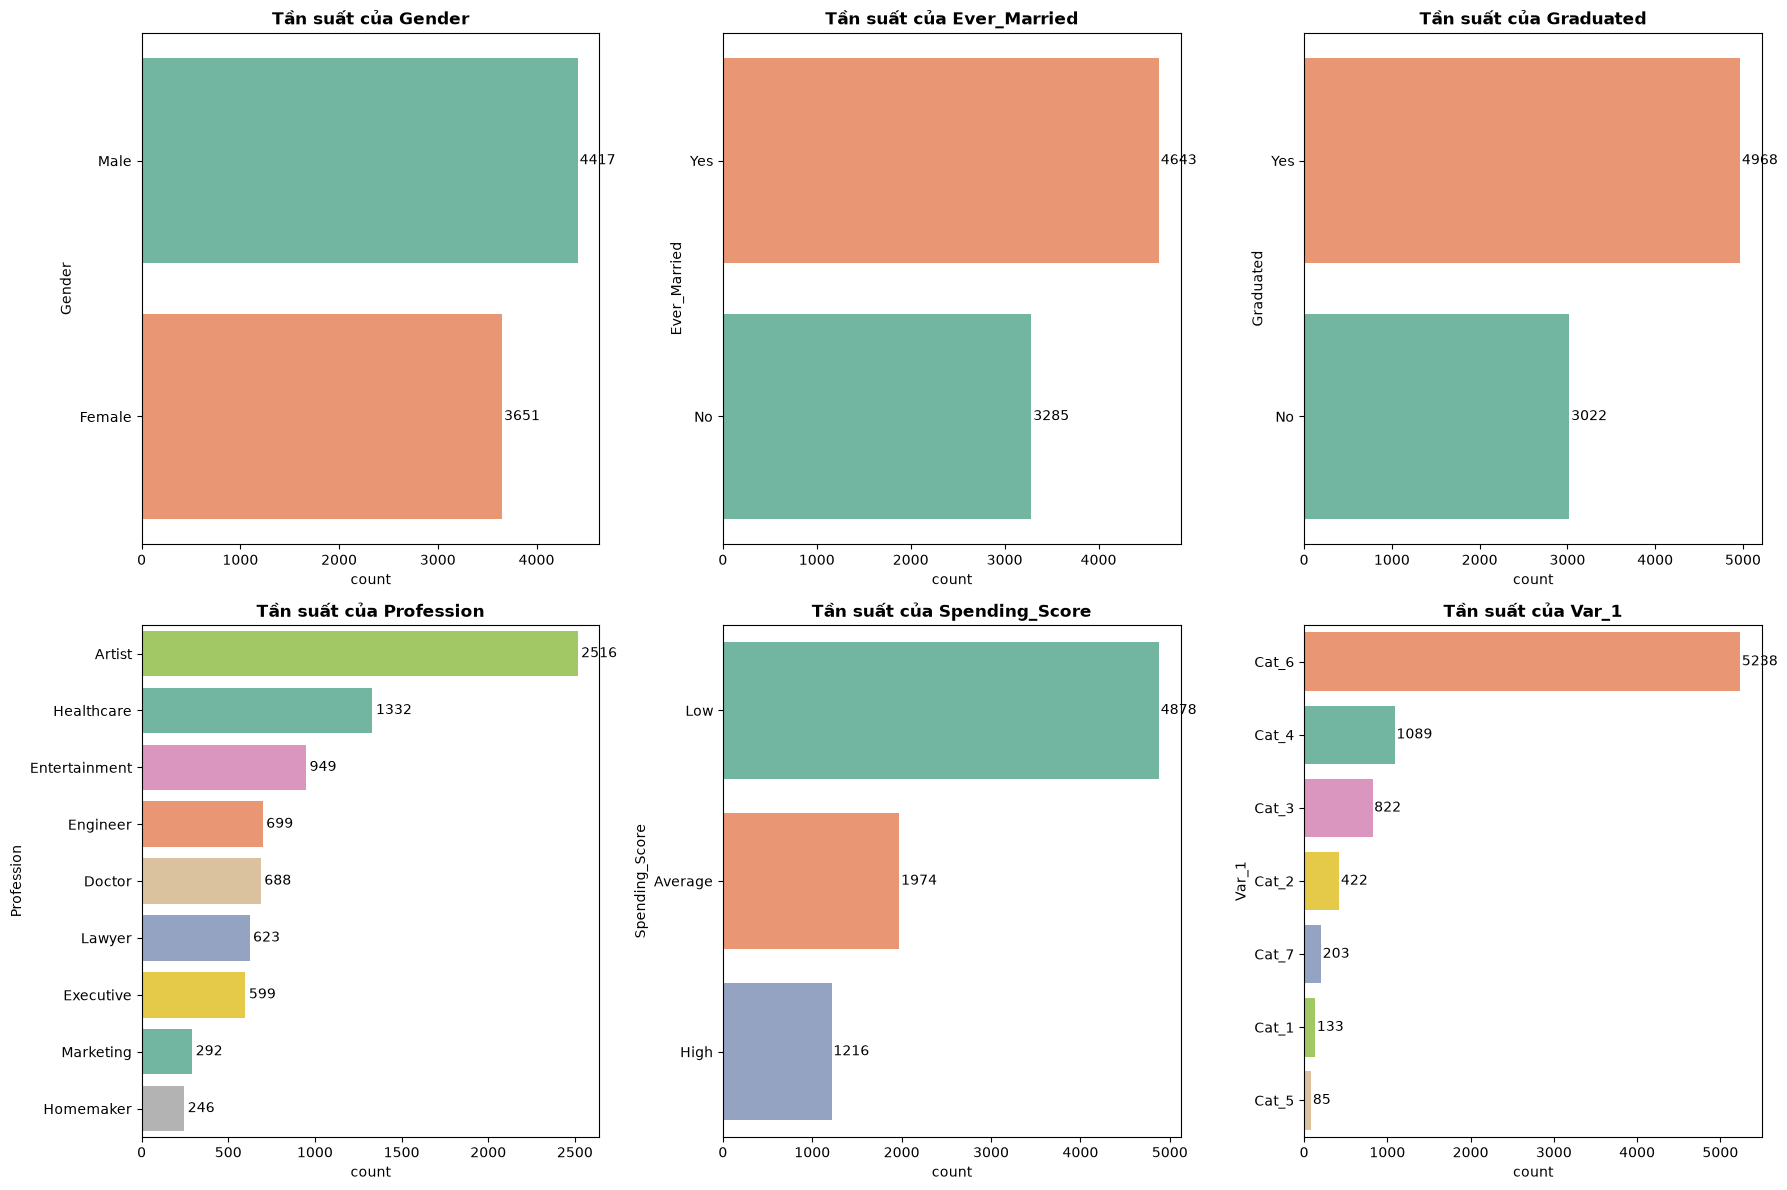

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):

    sns.countplot(
        y=eda_df[col],
        hue=eda_df[col],
        ax=axes[i],
        palette='Set2',
        legend=False,
        order=eda_df[col].value_counts().index
    )

    # Thêm số liệu lên đầu mỗi bar
    for p in axes[i].patches:
        width = p.get_width()

        axes[i].text(
            width + 20,                     # Dịch sang phải một chút
            p.get_y() + p.get_height()/2,   # Tâm của bar
            f'{int(width)}',
            va='center',
            fontsize=10
        )

    axes[i].set_title(
        f'Tần suất của {col}',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Nhìn chung, chỉ cho phép quan sát phân bố của từng thuộc tính riêng lẻ mà chưa đủ cơ sở để giải thích nguyên nhân của sự mất cân bằng giữa các nhóm giá trị. Do đó, nhóm sẽ tiếp tục chuyển sang bước phân tích đa biến (Multivariate Analysis) nhằm làm rõ mối quan hệ giữa các đặc trưng.

## 4. Multivariate Analysis